<h1 align="center"> Results </h1>

Import necessary libraries:

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import os
import numpy as np
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from pybiomart import Server
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy.stats import chi2

from src.optimise import capitalize_j, format_case_id

np.random.seed(2)

### Load Data

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [3]:
# Check length of both paired sample dataframes
print("Number of rows in paired radiomics samples:", df_merged2.shape[0])
print("Number of rows in paired RNA samples:", df_merged.shape[0])

Number of rows in paired radiomics samples: 36
Number of rows in paired RNA samples: 36


### Pair Images and RNA data

In [4]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

rna_paired_id_list = []
rad_paired_id_list = [] 

In [5]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id2)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [6]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id2)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [7]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rad)
print(f"Matching Images: ", flag2)

flag3 = (rna_paired_id_list == rad_paired_id_list)
print(f"Matching IDs: ", flag3)

Matching Diagnoses:  True
Matching Images:  True
Matching IDs:  True


### Train-test Split

In [8]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [9]:
# Step 1: Split into train and test sets
rad_train, rad_test, rna_train, rna_test, surg_train, surg_test, img_train, img_test, id_train, id_test = train_test_split(rad_data_filtered, rna_data_filtered, surgical_rad, image_filenames_rad, rad_paired_id_list, test_size=0.2, random_state=2)

In [10]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_data_filtered.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_data_filtered.columns)
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [11]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)
print(f"Diagnoses: ", id_train)

Number of RNA samples:  23
Number of radiomics samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']
Diagnoses:  ['24903', '14984', '14056', '25962', '26604', '26428', '18786', '14654', '16439', '14024', '25970', '25607', '14023', '16106', '26425', '26417', '25827', '18638', 'J630', '26379', '18853', '24354', '16134']


In [12]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of radiomics samples: ", rad_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)
print(f"Diagnoses: ", id_test)

Number of RNA samples:  6
Number of radiomics samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']
Diagnoses:  ['13291', '12930', '18852', '16208', '25961', '26424']


## Patient Demographics

In [13]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)
# Filter columns
surg_placeholder = df_radiomics["SURGICAL"]
df_radiomics.drop(["SURGICAL"], axis=1, inplace=True)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED
df_radiomics.insert(0, "SURGICAL", surg_placeholder)
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].str.strip() 
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["B-NS", "B-NS -->THEATRE", "NS"], "B-S")
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["M-NS"], "M-S")
df_radiomics["ID"] = df_radiomics["ID"].astype(str)
df_radiomics = df_radiomics.rename({"ID": "CASE ID"}, axis=1)
df_radiomics["CASE ID"] = df_radiomics["CASE ID"].astype("int64")

df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].str.strip() 
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].replace(["BENIGN", "MALIGNANT", "Benign", "BORDERLINE", "Borderline", "Malignant", "Malignnat", "malignant", "MALIGNANT - NON OVARIAN"], "Yes")
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].replace(["NA", "?Benign", "TBC"], "No")
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].fillna("No")

df_radiomics_meta_id = df_radiomics_meta[["CASE ID", "CASE ID2"]]

# Merge CASE ID2 
df_radiomics_corr = pd.merge(df_radiomics, df_radiomics_meta_id, how="left", on="CASE ID")
id_placeholder = df_radiomics_corr["CASE ID2"]
df_radiomics_corr.drop(["CASE ID2"], axis=1, inplace=True)
df_radiomics_corr.insert(2, "CASE ID2", id_placeholder)

In [14]:
df_radiomics_meta_id.loc[df_radiomics_meta_id["CASE ID"] == 28376]

,CASE ID,CASE ID2
37,28376,J623
38,28376,J613


In [15]:
df_radiomics_corr["CASE ID"] = df_radiomics_corr["CASE ID"].astype(str)
df_radiomics_corr["CASE ID2"] = df_radiomics_corr["CASE ID2"].astype(str)
df_radiomics_corr

,SURGICAL,CASE ID,CASE ID2,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,...,SOLID.DIAMETER,PP,P.FLOW,IRREG,AS,ASCITES,COLOUR.SCORE,CYST,CRESCE,MAHCINE_CORECCTED
0,B-S,11935,nan,144882.000000,144882.000000,291538.000000,2.012280,0.045859,21.830102,18.570425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
1,B-S,12041,nan,197549.000000,197549.000000,398241.000000,2.016728,0.042007,24.042893,20.382207,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
2,B-S,12165,nan,107498.000000,107498.000000,216576.000000,2.014698,0.050482,19.808851,16.817131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
3,M-S,12287,nan,155532.000000,155532.000000,312892.000000,2.011753,0.044707,22.369625,19.037510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
4,M-S,12665,nan,53293.000000,53293.000000,107786.000000,2.022520,0.063540,15.738315,13.275361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON S10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,B-S,756,nan,233536.250000,233536.250000,469333.250000,2.009764,0.039234,25.538184,21.770426,...,0.0,0,NA,1.0,1.0,0.0,2.0,LOW LEVEL,0,SAMSUNG W10
574,B-S,757,nan,171948.400000,171948.400000,345942.800000,2.012222,0.043817,22.981643,19.552589,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
575,B-S,759,nan,130348.666667,130348.666667,262413.333333,2.013769,0.048313,20.913305,17.771700,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
576,M-S,760,nan,76213.000000,76213.000000,153870.666667,2.019244,0.056766,17.658334,14.936394,...,25.0,0,0,1.0,0.0,0.0,1.0,LOW LEVEL,0,SAMSUNG W10


In [16]:
rad_train_case_id = df_radiomics_corr[df_radiomics_corr["CASE ID"].isin(id_train)]
rad_train_case_id2 = df_radiomics_corr[df_radiomics_corr["CASE ID2"].isin(id_train)]
rad_train_df = pd.concat([rad_train_case_id, rad_train_case_id2],ignore_index=True)
rad_train_df["CASE ID2"] = rad_train_df["CASE ID2"].replace("nan", np.nan, regex=True)

In [17]:
rad_train_df

,SURGICAL,CASE ID,CASE ID2,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,...,SOLID.DIAMETER,PP,P.FLOW,IRREG,AS,ASCITES,COLOUR.SCORE,CYST,CRESCE,MAHCINE_CORECCTED
0,M-S,14023,NaN,130140.000000,130140.000000,263738.000000,2.026571,0.047089,21.236424,17.853391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
1,M-S,14024,NaN,127698.000000,127698.000000,258430.000000,2.024601,0.047725,21.013648,17.698956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
2,M-S,14056,NaN,188300.000000,188300.000000,379747.000000,2.016933,0.041849,23.899112,20.253480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
3,M-S,14654,NaN,120428.500000,120428.500000,242746.000000,2.016713,0.050215,20.262443,17.178528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
4,M-S,14984,NaN,207071.333333,207071.333333,420950.000000,2.033386,0.040467,24.792772,20.729964,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
5,B-S,16106,NaN,167856.666667,167856.666667,340079.333333,2.026380,0.043327,23.095454,19.421396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
6,M-S,16134,NaN,177640.500000,177640.500000,357289.500000,2.011457,0.043129,23.281164,19.818941,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
7,B-S,16439,NaN,179041.500000,179041.500000,360077.000000,2.011170,0.042713,23.425721,19.946110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
8,M-S,18638,NaN,155032.750000,155032.750000,313215.500000,2.020632,0.044763,22.393314,18.920006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
9,M-S,18786,NaN,272937.000000,272937.000000,548326.000000,2.008984,0.037110,26.947166,22.985904,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON S10


In [18]:
rad_test_case_id = df_radiomics_corr[df_radiomics_corr["CASE ID"].isin(id_test)]
rad_test_case_id2 = df_radiomics_corr[df_radiomics_corr["CASE ID2"].isin(id_test)]
rad_test_df = pd.concat([rad_test_case_id, rad_test_case_id2],ignore_index=True)
rad_test_df["CASE ID2"] = rad_test_df["CASE ID2"].replace("nan", np.nan, regex=True)

In [19]:
rad_test_df

,SURGICAL,CASE ID,CASE ID2,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,...,SOLID.DIAMETER,PP,P.FLOW,IRREG,AS,ASCITES,COLOUR.SCORE,CYST,CRESCE,MAHCINE_CORECCTED
0,B-S,12930,NaN,182434.000000,182434.000000,369546.000000,2.025642,0.042094,23.756394,19.987195,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
1,M-S,13291,NaN,144631.666667,144631.666667,293124.666667,2.026885,0.045875,21.901476,18.408765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
2,B-S,16208,NaN,88090.500000,88090.500000,177644.000000,2.016617,0.053899,18.553882,15.726765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
3,B-S,18852,NaN,110868.500000,110868.500000,223272.000000,2.014504,0.050759,19.853728,16.861080,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG WS80
4,M-S,25961,J452,188038.000000,188038.000000,380854.000000,2.025410,0.041676,23.994442,20.191334,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON S10
5,M-S,26424,J524,73093.000000,73093.000000,149292.000000,2.042494,0.056628,17.659099,14.653560,...,137.0,0.0,NaN,NaN,0.0,1.0,2.0,NaN,NaN,SAMSUNG W10


In [20]:
id_val = rad_train_df["CASE ID"].tolist() + rad_test_df["CASE ID"].tolist()
len(id_val) 

29

In [21]:
rad_val_df = df_radiomics_corr[~df_radiomics_corr["CASE ID"].isin(id_val)]
rad_val_df["CASE ID2"] = rad_val_df["CASE ID2"].replace("nan", np.nan, regex=True)

/tmp/ipykernel_90793/3640657105.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rad_val_df["CASE ID2"] = rad_val_df["CASE ID2"].replace("nan", np.nan, regex=True)


In [22]:
rad_val_df

,SURGICAL,CASE ID,CASE ID2,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,...,SOLID.DIAMETER,PP,P.FLOW,IRREG,AS,ASCITES,COLOUR.SCORE,CYST,CRESCE,MAHCINE_CORECCTED
0,B-S,11935,NaN,144882.000000,144882.000000,291538.000000,2.012280,0.045859,21.830102,18.570425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
1,B-S,12041,NaN,197549.000000,197549.000000,398241.000000,2.016728,0.042007,24.042893,20.382207,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
2,B-S,12165,NaN,107498.000000,107498.000000,216576.000000,2.014698,0.050482,19.808851,16.817131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
3,M-S,12287,NaN,155532.000000,155532.000000,312892.000000,2.011753,0.044707,22.369625,19.037510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
4,M-S,12665,NaN,53293.000000,53293.000000,107786.000000,2.022520,0.063540,15.738315,13.275361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON S10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,B-S,756,NaN,233536.250000,233536.250000,469333.250000,2.009764,0.039234,25.538184,21.770426,...,0.0,0,NA,1.0,1.0,0.0,2.0,LOW LEVEL,0,SAMSUNG W10
574,B-S,757,NaN,171948.400000,171948.400000,345942.800000,2.012222,0.043817,22.981643,19.552589,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
575,B-S,759,NaN,130348.666667,130348.666667,262413.333333,2.013769,0.048313,20.913305,17.771700,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
576,M-S,760,NaN,76213.000000,76213.000000,153870.666667,2.019244,0.056766,17.658334,14.936394,...,25.0,0,0,1.0,0.0,0.0,1.0,LOW LEVEL,0,SAMSUNG W10


In [23]:
# Number of patients
print(f"Number patients Train (n):", rad_train_df["CASE ID"].nunique())
print(f"Number patients Validation (n):", rad_test_df["CASE ID"].nunique())
print(f"Number patients Test (n):", rad_val_df["CASE ID"].nunique())

Number patients Train (n): 23
Number patients Validation (n): 6
Number patients Test (n): 548


In [24]:
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
image_id_list = []
image_count = 0

for index, row in rad_train_df.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id)
                    image_count += 1

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id2)
                    image_count += 1

In [25]:
# Number of images
print(f"Number of Samples Train: ", image_count)

Number of Samples Train:  65


In [26]:
# Create dataframe
images_dict = {"image_name": image_filenames, "ID": image_id_list}
images_train_df = pd.DataFrame(images_dict)
images_train_df

,image_name,ID
0,14023_3.nii.gz,14023
1,14024_2.nii.gz,14024
2,14024_3.nii.gz,14024
3,14056_3.nii.gz,14056
4,14056_2.nii.gz,14056
...,...,...
60,26604_0001.nii.gz,26604
61,J630_0008.nii.gz,J630
62,J630_0011.nii.gz,J630
63,J630_0009.nii.gz,J630


In [27]:
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
image_id_list = []
image_count = 0

for index, row in rad_test_df.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id)
                    image_count += 1

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id2)
                    image_count += 1

In [28]:
# Number of images
print(f"Number of Samples Validation: ", image_count)

Number of Samples Validation:  10


In [29]:
# Create dataframe
images_dict = {"image_name": image_filenames, "ID": image_id_list}
images_test_df = pd.DataFrame(images_dict)
images_test_df

,image_name,ID
0,12930_3.nii.gz,12930
1,13291_0010.nii.gz,13291
2,13291_0008.nii.gz,13291
3,13291_0009.nii.gz,13291
4,16208_1.nii.gz,16208
5,16208_4.nii.gz,16208
6,18852_0009.nii.gz,18852
7,18852_0008.nii.gz,18852
8,25961_2.nii.gz,25961
9,26424_0007.nii.gz,26424


In [30]:
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
image_id_list = []
image_count = 0

for index, row in rad_val_df.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id)
                    image_count += 1

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id2)
                    image_count += 1

In [31]:
# Number of images
print(f"Number of Samples Test: ", image_count)

Number of Samples Test:  1315


In [32]:
# Create dataframe
images_dict = {"image_name": image_filenames, "ID": image_id_list}
images_val_df = pd.DataFrame(images_dict)
images_val_df

,image_name,ID
0,11935_6.nii.gz,11935
1,11935_3.nii.gz,11935
2,12165_2.nii.gz,12165
3,12287_4.nii.gz,12287
4,12287_5.nii.gz,12287
...,...,...
1310,J760_0015.nii.gz,760
1311,J765_0019.nii.gz,765
1312,J765_0020.nii.gz,765
1313,J765_0021.nii.gz,765


Text(0.5, 1.0, 'Test')

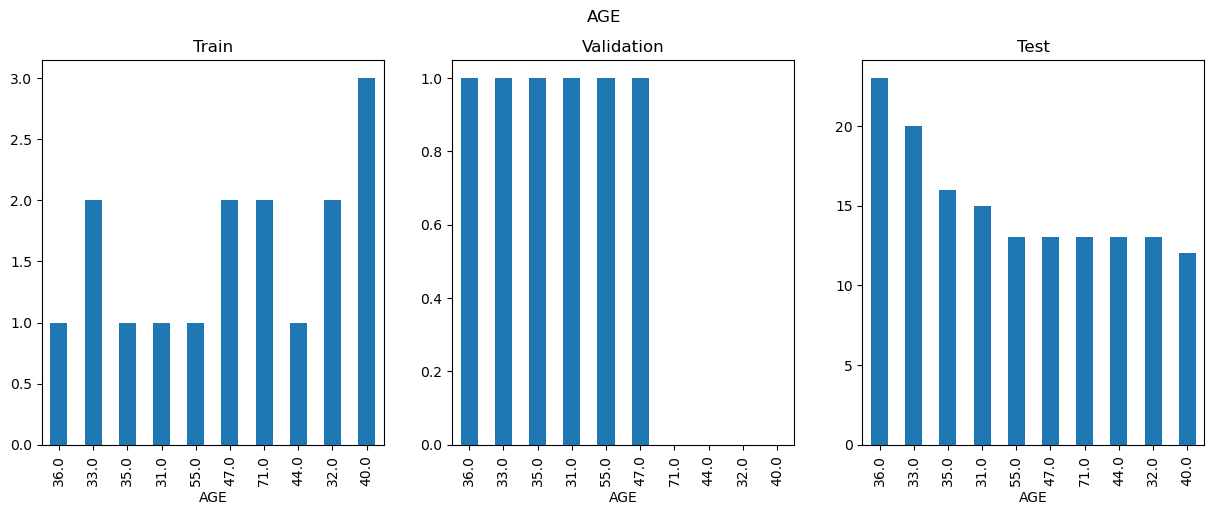

In [33]:
fig, axes = plt.subplots(1, 3, sharex=True, figsize=(15,5))
fig.suptitle("AGE")

rad_train_df["AGE"].value_counts().sort_index().head(10).plot.bar(ax=axes[0])
axes[0].set_title("Train")

rad_test_df["AGE"].value_counts().head(10).plot.bar(ax=axes[1])
axes[1].set_title("Validation")

rad_val_df["AGE"].value_counts().head(10).plot.bar(ax=axes[2])
axes[2].set_title("Test")

In [34]:
# Age: median (IQR) years
age_train = rad_train_df[["AGE"]]
age_train["AGE"] = pd.to_numeric(age_train["AGE"])
print(f"Train Age median: ", age_train.median())
# Calculate interquartile range of values
q75, q25 = np.percentile(age_train["AGE"], [75 ,25])
print(f"Train Q1: ", q25)
print(f"Train Q3: ", q75)

Train Age median:  AGE    60.0
dtype: float64
Train Q1:  51.5
Train Q3:  64.0


/tmp/ipykernel_90793/3497790840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_train["AGE"] = pd.to_numeric(age_train["AGE"])


In [35]:
# Age: median (IQR) years
age_test = rad_test_df[["AGE"]]
age_test["AGE"] = pd.to_numeric(age_test["AGE"])
print(f"Validation Age median: ", age_test.median())
# Calculate interquartile range of values
q75, q25 = np.percentile(age_test["AGE"], [75 ,25])
print(f"Validation Q1: ", q25)
print(f"Validation Q3: ", q75)

Validation Age median:  AGE    51.5
dtype: float64
Validation Q1:  44.75
Validation Q3:  56.75


/tmp/ipykernel_90793/1626686853.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_test["AGE"] = pd.to_numeric(age_test["AGE"])


In [36]:
# Age: median (IQR) years
age_val = rad_val_df[["AGE"]]
age_val["AGE"] = pd.to_numeric(age_val["AGE"], errors="coerce")
age_val["AGE"] = age_val["AGE"].fillna(age_val["AGE"].median())
print(f"Test Age median: ", age_val.median())
# Calculate interquartile range of values
q75, q25 = np.percentile(age_val["AGE"], [75 ,25])
print(f"Test Q1: ", q25)
print(f"Test Q3: ", q75)

Test Age median:  AGE    44.0
dtype: float64
Test Q1:  35.0
Test Q3:  59.0


/tmp/ipykernel_90793/4255141299.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_val["AGE"] = pd.to_numeric(age_val["AGE"], errors="coerce")
/tmp/ipykernel_90793/4255141299.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_val["AGE"] = age_val["AGE"].fillna(age_val["AGE"].median())


In [37]:
# Calculate p-value
stat, p_value = mannwhitneyu(age_train, age_test)
print(f'Train - Val: Statistic: {stat}, p-value: {p_value}')

Train - Val: Statistic: [91.5], p-value: [0.23548765]


In [38]:
stat, p_value = mannwhitneyu(age_train, age_val)
print(f'Train - Test: Statistic: {stat}, p-value: {p_value}')

Train - Test: Statistic: [8832.], p-value: [0.00109744]


In [39]:
# Number of images
images_train_dup = images_train_df.pivot_table(index=["ID"], aggfunc="size")
images_train_dup = images_train_dup.reset_index()
images_train_dup = images_train_dup.rename({0: "Count"}, axis=1)
print(f"Train Images median: ", images_train_dup["Count"].median())
# Calculate interquartile range of values
q75, q25 = np.percentile(images_train_dup["Count"], [75 ,25])
print(f"Train Q1: ", q25)
print(f"Train Q3: ", q75)

Train Images median:  3.0
Train Q1:  2.0
Train Q3:  4.0


In [40]:
# Number of images
images_test_dup = images_test_df.pivot_table(index=["ID"], aggfunc="size")
images_test_dup = images_test_dup.reset_index()
images_test_dup = images_test_dup.rename({0: "Count"}, axis=1)
print(f"Validation Images median: ", images_test_dup["Count"].median())
# Calculate interquartile range of values
q75, q25 = np.percentile(images_test_dup["Count"], [75 ,25])
print(f"Validation Q1: ", q25)
print(f"Validation Q3: ", q75)

Validation Images median:  1.5
Validation Q1:  1.0
Validation Q3:  2.0


In [41]:
# Number of images
images_val_dup = images_val_df.pivot_table(index=["ID"], aggfunc="size")
images_val_dup = images_val_dup.reset_index()
images_val_dup = images_val_dup.rename({0: "Count"}, axis=1)
print(f"Test Images median: ", images_val_dup["Count"].median())
# Calculate interquartile range of values
q75, q25 = np.percentile(images_val_dup["Count"], [75 ,25])
print(f"Test Q1: ", q25)
print(f"Test Q3: ", q75)

Test Images median:  2.0
Test Q1:  2.0
Test Q3:  3.0


In [42]:
# Diagnosis
counts = rad_train_df["SURGICAL"].value_counts() 
percs = rad_train_df["SURGICAL"].value_counts(normalize=True)
pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])

,count,percentage
SURGICAL,,
M-S,20,0.869565
B-S,3,0.130435


In [43]:
# Diagnosis
counts = rad_test_df["SURGICAL"].value_counts() 
percs = rad_test_df["SURGICAL"].value_counts(normalize=True)
pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])

,count,percentage
SURGICAL,,
B-S,3,0.5
M-S,3,0.5


In [44]:
# Diagnosis
counts = rad_val_df["SURGICAL"].value_counts() 
percs = rad_val_df["SURGICAL"].value_counts(normalize=True)
pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])

,count,percentage
SURGICAL,,
B-S,439,0.801095
M-S,109,0.198905


Text(0.5, 1.0, 'Test')

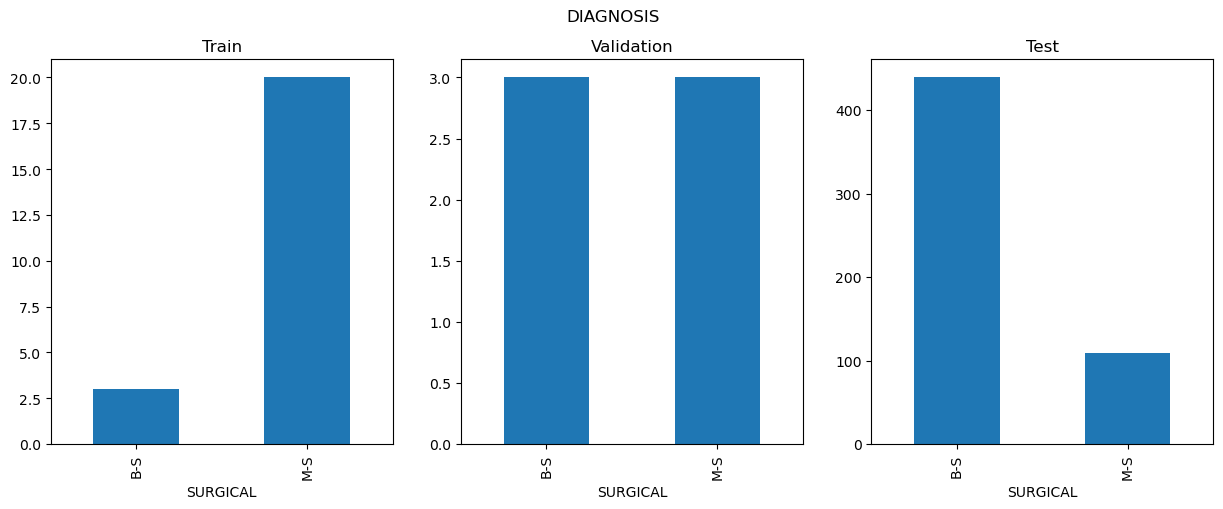

In [45]:
fig, axes = plt.subplots(1, 3, sharex=True, figsize=(15,5))
fig.suptitle("DIAGNOSIS")

rad_train_df["SURGICAL"].value_counts().sort_index().head(2).plot.bar(ax=axes[0])
axes[0].set_title("Train")

rad_test_df["SURGICAL"].value_counts().head(2).plot.bar(ax=axes[1])
axes[1].set_title("Validation")

rad_val_df["SURGICAL"].value_counts().head(2).plot.bar(ax=axes[2])
axes[2].set_title("Test")

<Axes: >

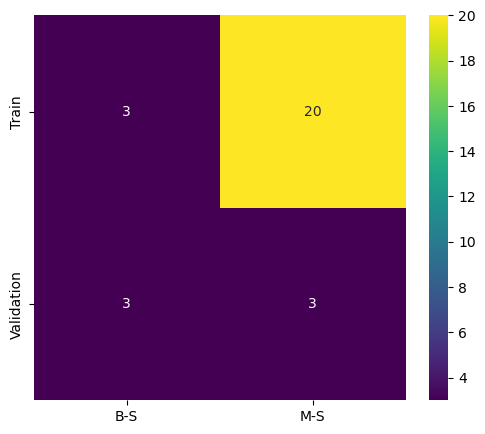

In [46]:
# Calculate p-value Train - Validation
table_TV = [[3, 20],
         [3,  3]]
plt.figure(figsize=(6,5)) 
x_axis_labels = ['B-S', 'M-S']
y_axis_labels = ['Train', 'Validation']
sns.heatmap(table_TV, annot=True, cmap="viridis",xticklabels=x_axis_labels, yticklabels=y_axis_labels)

In [47]:
stat, p, dof, expected = chi2_contingency(table_TV)
print(f"Train - Validation: P-value:  ", p)

Train - Validation: P-value:   0.15434892188276353


<Axes: >

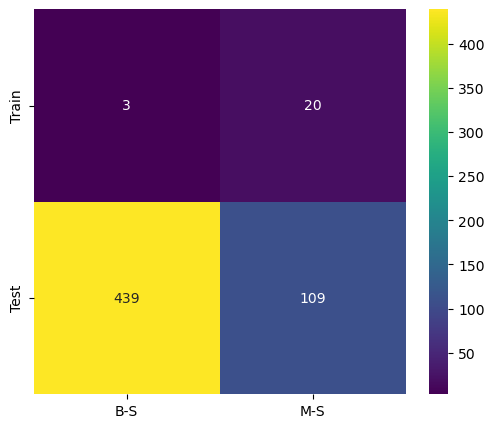

In [48]:
# Calculate p-value Train - Test
table_TT = [[3, 20],
         [439,  109]]
plt.figure(figsize=(6,5)) 
x_axis_labels = ['B-S', 'M-S']
y_axis_labels = ['Train', 'Test']
sns.heatmap(table_TT, annot=True, cmap="viridis",xticklabels=x_axis_labels, yticklabels=y_axis_labels, fmt=',d')

In [49]:
stat, p, dof, expected = chi2_contingency(table_TT)
print(f"Train - Test: P-value:  ", p)

Train - Test: P-value:   3.3317242557074863e-13


In [50]:
# Histology
counts = rad_train_df["HISTOLOGY"].value_counts() 
percs = rad_train_df["HISTOLOGY"].value_counts(normalize=True)
pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])

,count,percentage
HISTOLOGY,,
Yes,23,1.0


In [51]:
# Histology
counts = rad_test_df["HISTOLOGY"].value_counts() 
percs = rad_test_df["HISTOLOGY"].value_counts(normalize=True)
pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])

,count,percentage
HISTOLOGY,,
Yes,6,1.0


In [52]:
# Histology
counts = rad_val_df["HISTOLOGY"].value_counts() 
percs = rad_val_df["HISTOLOGY"].value_counts(normalize=True)
pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])

,count,percentage
HISTOLOGY,,
No,290,0.529197
Yes,258,0.470803


<Axes: >

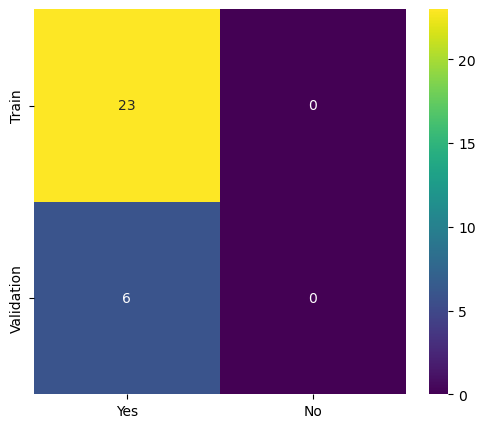

In [53]:
# Calculate p-value Train - Validation
table_TV = [[23, 0],
         [6,  0]]
plt.figure(figsize=(6,5)) 
x_axis_labels = ['Yes', 'No']
y_axis_labels = ['Train', 'Validation']
sns.heatmap(table_TV, annot=True, cmap="viridis",xticklabels=x_axis_labels, yticklabels=y_axis_labels)

In [54]:
# stat, p, dof, expected = chi2_contingency(table_TV)
# print(f"Train - Validation: P-value:  ", p)

ValueError: The internally computed table of expected frequencies has a zero element at (0, 1).

<Axes: >

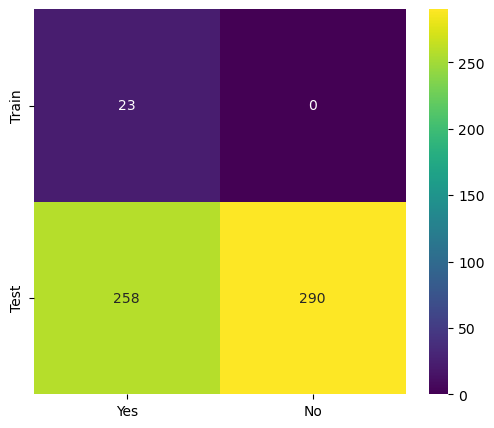

In [55]:
# Calculate p-value Train - Test
table_TT = [[23, 0],
         [258,  290]]
plt.figure(figsize=(6,5)) 
x_axis_labels = ['Yes', 'No']
y_axis_labels = ['Train', 'Test']
sns.heatmap(table_TT, annot=True, cmap="viridis",xticklabels=x_axis_labels, yticklabels=y_axis_labels, fmt=',d')

In [56]:
stat, p, dof, expected = chi2_contingency(table_TT)
print(f"Train - Test: P-value:  ", p)

Train - Test: P-value:   1.93260625824979e-06


In [58]:
# CA125
rad_train_df["CA125"] = pd.to_numeric(rad_train_df["CA125"], errors="coerce")
rad_train_df["CA125"] = rad_train_df["CA125"].fillna(rad_train_df["CA125"].median())

rad_test_df["CA125"] = pd.to_numeric(rad_test_df["CA125"], errors="coerce")
rad_test_df["CA125"] = rad_test_df["CA125"].fillna(rad_test_df["CA125"].median())

rad_val_df["CA125"] = pd.to_numeric(rad_val_df["CA125"], errors="coerce")
rad_val_df["CA125"] = rad_val_df["CA125"].fillna(rad_val_df["CA125"].median())

/tmp/ipykernel_90793/3240535544.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rad_val_df["CA125"] = pd.to_numeric(rad_val_df["CA125"], errors="coerce")
/tmp/ipykernel_90793/3240535544.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rad_val_df["CA125"] = rad_val_df["CA125"].fillna(rad_val_df["CA125"].median())


Text(0.5, 1.0, 'Test')

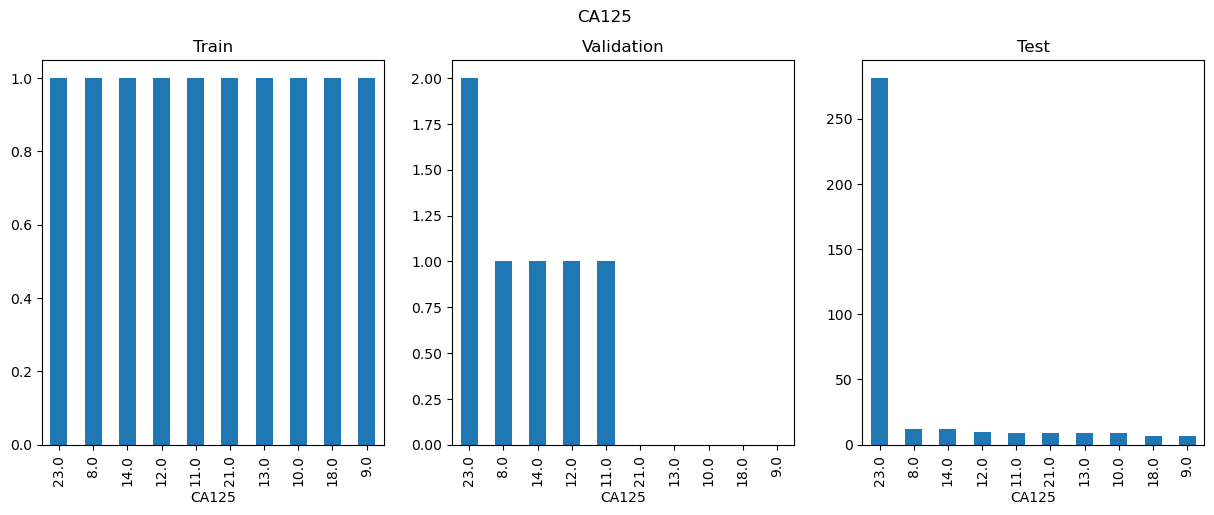

In [59]:
fig, axes = plt.subplots(1, 3, sharex=True, figsize=(15,5))
fig.suptitle("CA125")

rad_train_df["CA125"].value_counts().sort_index().head(10).plot.bar(ax=axes[0])
axes[0].set_title("Train")

rad_test_df["CA125"].value_counts().head(10).plot.bar(ax=axes[1])
axes[1].set_title("Validation")

rad_val_df["CA125"].value_counts().head(10).plot.bar(ax=axes[2])
axes[2].set_title("Test")

In [60]:
# CA125: median (IQR) years
CA125_train = rad_train_df[["CA125"]]
print(f"Train CA125 median: ", CA125_train.median())
# Calculate interquartile range of values
q75, q25 = np.percentile(CA125_train["CA125"], [75 ,25])
print(f"Train Q1: ", q25)
print(f"Train Q3: ", q75)

Train CA125 median:  CA125    122.0
dtype: float64
Train Q1:  46.0
Train Q3:  429.0


In [64]:
rad_train_df[["CA125", "SURGICAL"]]

,CA125,SURGICAL
0,25.0,M-S
1,39.0,M-S
2,122.0,M-S
3,27.0,M-S
4,2007.0,M-S
5,53.0,B-S
6,252.0,M-S
7,122.0,B-S
8,122.0,M-S
9,17.0,M-S


In [65]:
# CA125: median (IQR) years
CA125_test = rad_test_df[["CA125"]]
print(f"Validation CA125 median: ", CA125_test.median())
# Calculate interquartile range of values
q75, q25 = np.percentile(CA125_test["CA125"], [75 ,25])
print(f"Validation Q1: ", q25)
print(f"Validation Q3: ", q75)

Validation CA125 median:  CA125    127.0
dtype: float64
Validation Q1:  108.25
Validation Q3:  445.75


In [66]:
rad_test_df[["CA125", "SURGICAL"]]

,CA125,SURGICAL
0,26.0,B-S
1,552.0,M-S
2,102.0,B-S
3,127.0,B-S
4,1387.0,M-S
5,127.0,M-S


In [67]:
# CA125: median (IQR) years
CA125_val = rad_val_df[["CA125"]]
print(f"Test CA125 median: ", CA125_val.median())
# Calculate interquartile range of values
q75, q25 = np.percentile(CA125_val["CA125"], [75 ,25])
print(f"Test Q1: ", q25)
print(f"Test Q3: ", q75)

Test CA125 median:  CA125    23.0
dtype: float64
Test Q1:  23.0
Test Q3:  23.0


In [68]:
rad_val_df[["CA125", "SURGICAL"]]

,CA125,SURGICAL
0,23.0,B-S
1,13.0,B-S
2,23.0,B-S
3,288.0,M-S
4,272.0,M-S
...,...,...
573,11.0,B-S
574,23.0,B-S
575,23.0,B-S
576,225.0,M-S


In [69]:
# Calculate p-value
stat, p_value = mannwhitneyu(CA125_train, CA125_test)
print(f'Train - Val: Statistic: {stat}, p-value: {p_value}')

Train - Val: Statistic: [59.], p-value: [0.60854107]


In [70]:
stat, p_value = mannwhitneyu(CA125_train, CA125_val)
print(f'Train - Test: Statistic: {stat}, p-value: {p_value}')

Train - Test: Statistic: [10106.5], p-value: [1.70087081e-07]
